# SynthItaly — predicting debtors & climbers from behaviour

**Question.** Using only what a bank observes, can we predict **who is a debtor** and, among
debtors, **who is a climber** (the archetype that digs out of debt)? We run each task twice:

- **Naive** — every feature, including the debt-mechanic proxies (`LEAK_` columns: overdraft
  fees, credit draws, debt-service lines, savings/pension balances). These *mechanically*
  encode the label, so accuracy should be near-perfect. Its job is to confirm the behaviours
  are faithfully encoded in the data.
- **Fair** — those proxies removed. Can *ordinary* behaviour (spending, bills, income,
  balance dynamics) still flag a future debtor / a climber? This is the genuinely interesting
  test, and the realistic one.

> **Circularity caveat (same as `clustering.ipynb`).** Behaviours are generated from latent
> labels, so the naive task is partly tautological. The fair task is the meaningful one. None
> of this claims real-world predictability — it validates that the *intended* behavioural
> separation exists and is learnable. Data generation: `../docs/WALKTHROUGH.md`.

## 1 · Setup & data

In [1]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from synthitaly import numbers
from synthitaly.model import ItalyModel

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
RNG_SEED = 42

# A long horizon (720 days ~ 24 months) so climbers can dig out of debt and the
# three debtor trajectories fully separate; 800 consumers so every archetype is
# populated. This is the same model the rest of the repo ships -- nothing here
# touches the simulation, we only ANALYSE its output.
model = ItalyModel(n_consumers=800, n_merchants_per_category=3, n_days=720, seed=RNG_SEED)
model.run()

df_tx = pd.DataFrame(model.transactions)
df_tx["date"] = pd.to_datetime(df_tx["date"])
df_acc = pd.DataFrame(model.export_accounts())
print("transactions:", df_tx.shape, "| accounts:", df_acc.shape)
df_tx.head(3)

transactions: (381350, 7) | accounts: (2400, 17)


,date,kind,from,to,category,amount_eur,macro_area
0,2017-01-01,purchase,856,6,retail,13.89,CENTRE
1,2017-01-01,purchase,447,40,clothing,25.12,CENTRE
2,2017-01-01,bill,297,98,rent,440.00,CENTRE


## 2 · Features & labels (one row per consumer)

In [2]:
# Feature engineering: one row per CONSUMER, derived from the two exported tables
# (transactions + accounts). Identical to clustering.ipynb because both now import the
# same implementation — synthitaly.features — rather than each carrying a copy.
#
#   FAIR   columns are signals a bank could see from ordinary activity.
#   LEAK_  columns are debt-mechanic proxies that *mechanically* encode the label
#          (overdraft fees, credit draws, debt-service lines, savings/pension balances).
from synthitaly import features as F

feats = F.build_features(model)
labels = F.label_frame(model)
data = feats.merge(labels, on="consumer_id")

FEAT_COLS = F.feature_columns(feats)
LEAK_COLS = F.leak_columns(feats)
FAIR_COLS = F.fair_columns(feats)
MONEY_COLS = F.money_columns(FEAT_COLS)
print(f"{len(FAIR_COLS)} fair features + {len(LEAK_COLS)} leakage features; {feats.isna().sum().sum()} NaNs")
data["debtor_subtype"].value_counts()

35 fair features + 10 leakage features; 0 NaNs


debtor_subtype
none         643
climber       83
chronic       38
subsister     36
Name: count, dtype: int64

**Label note.** `is_debtor` is `debtor_subtype is not None` — the *assigned* debt status —
**not** the end-of-run `has_debt`, because climbers who dig out flip `has_debt` to `False`. So
we predict who was *ever* set up as a debtor. `is_climber` is defined among debtors only.

In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (ConfusionMatrixDisplay, RocCurveDisplay, classification_report,
                             roc_auc_score)
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

ALL_COLS = FEAT_COLS          # fair + LEAK_, the "naive" feature set
# FAIR_COLS / MONEY_COLS come from synthitaly.features (cell above).


def Xframe(frame, cols):
    """log1p the heavy-tailed money columns; leave shares/counts alone."""
    X = frame[cols].copy()
    for m in F.money_columns(cols):
        X[m] = np.log1p(X[m].clip(lower=0))
    return X


def evaluate(frame, y, title):
    """Fit LR + RF under naive (all) and fair (no-leak) feature sets; report AUC + reports."""
    out = {}
    for tag, cols in [("naive", ALL_COLS), ("fair", FAIR_COLS)]:
        X = Xframe(frame, cols)
        models = {
            "LogReg": make_pipeline(StandardScaler(),
                                    LogisticRegression(max_iter=2000, class_weight="balanced")),
            "RandForest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=0),
        }
        for name, mdl in models.items():
            auc = cross_val_score(mdl, X, y, cv=5, scoring="roc_auc").mean()
            out[(tag, name)] = auc
    base = cross_val_score(DummyClassifier(strategy="most_frequent"),
                           Xframe(frame, FAIR_COLS), y, cv=5, scoring="roc_auc").mean()
    res = pd.Series(out).unstack().round(3)
    res.loc["baseline"] = [base, base]
    print(f"=== {title} — 5-fold ROC-AUC ===")
    display(res)
    return res

## 3 · Task 1 — who is a debtor? *(all consumers)*

In [4]:
y_deb = data["is_debtor"].astype(int)
print("class balance:", y_deb.value_counts().to_dict())
res_deb = evaluate(feats, y_deb, "Task 1: debtor vs non-debtor")

class balance: {0: 643, 1: 157}


=== Task 1: debtor vs non-debtor — 5-fold ROC-AUC ===


,LogReg,RandForest
fair,0.697,0.745
naive,1.000,1.000
baseline,0.500,0.500


Fair LogReg classification report (held-out):
               precision    recall  f1-score   support

  non-debtor       0.83      0.68      0.75       193
      debtor       0.25      0.43      0.31        47

    accuracy                           0.63       240
   macro avg       0.54      0.55      0.53       240
weighted avg       0.72      0.63      0.66       240



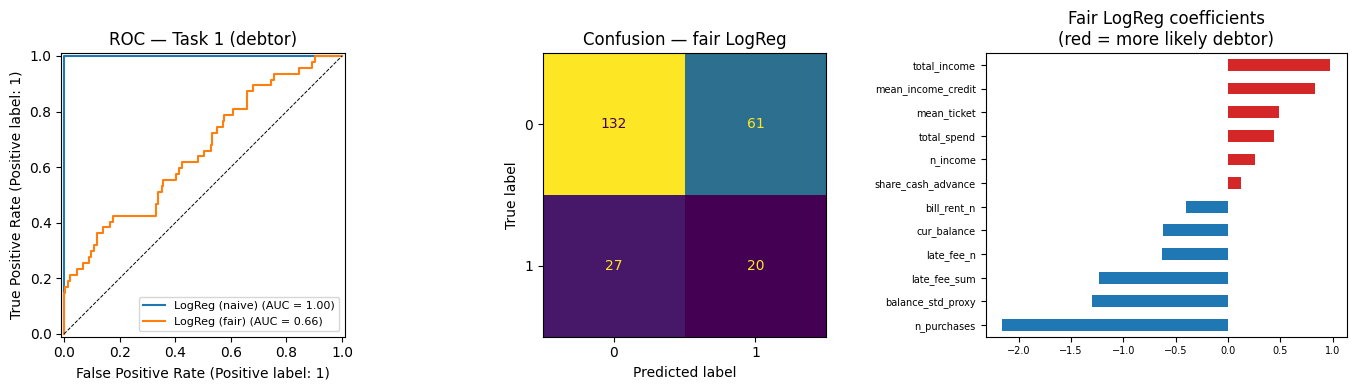

In [5]:
# A held-out split for the confusion matrix + ROC curves (naive vs fair, LogReg).
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for tag, cols, colr in [("naive", ALL_COLS, "tab:gray"), ("fair", FAIR_COLS, "tab:blue")]:
    X = Xframe(feats, cols)
    Xtr, Xte, ytr, yte = train_test_split(X, y_deb, test_size=0.3, stratify=y_deb, random_state=0)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")).fit(Xtr, ytr)
    RocCurveDisplay.from_estimator(clf, Xte, yte, ax=ax[0], name=f"LogReg ({tag})")
    if tag == "fair":
        ConfusionMatrixDisplay.from_estimator(clf, Xte, yte, ax=ax[1], colorbar=False)
        ax[1].set_title("Confusion — fair LogReg")
        print("Fair LogReg classification report (held-out):\n",
              classification_report(yte, clf.predict(Xte), target_names=["non-debtor", "debtor"]))
ax[0].plot([0, 1], [0, 1], "k--", lw=0.7); ax[0].set_title("ROC — Task 1 (debtor)"); ax[0].legend(fontsize=8)
# which behaviours predict debt? top fair LogReg coefficients.
# cur_total_in is dropped HERE ONLY: it is r=0.9997 with total_income, which splits the
# income signal arbitrarily between the two (+1.36/+0.27 with it, +0.98/+0.83 without).
# See synthitaly.features.COLLINEAR_DUPLICATES. The AUC tables above keep the full fair
# set -- the predictive cost of dropping it is 0.6965 -> 0.6944.
COEF_COLS = F.interpretable_columns(FAIR_COLS)
Xf = Xframe(feats, COEF_COLS)
coef = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")).fit(Xf, y_deb)
imp = pd.Series(coef.named_steps["logisticregression"].coef_[0], index=COEF_COLS).sort_values()
top = pd.concat([imp.head(6), imp.tail(6)])
top.plot.barh(ax=ax[2], color=(top > 0).map({True: "tab:red", False: "tab:blue"}))
ax[2].set_title("Fair LogReg coefficients\n(red = more likely debtor)"); ax[2].tick_params(labelsize=7)
fig.tight_layout(); plt.show()

**Reading Task 1.** The **naive** model is exactly perfect (**AUC = 1.000**, both LogReg and
random forest) — unsurprising, since a debt-service line *is* the label. The honest result is
the **fair** model: **LogReg 0.697, random forest 0.745** against a 0.500 baseline. Ordinary
behaviour carries real but modest signal — clearly above chance, nowhere near the naive
ceiling, and the held-out confusion matrix shows what that means in practice (debtor precision
0.25 at recall 0.43). The random forest beating the linear model is the expected sign that
what signal exists is non-linear rather than a clean income gradient.

> **This number was 0.91 until the feature set was audited.** The difference was a single
> column, `cur_n_entries`, which counts *every* current-account entry — including the
> debt-service, credit-draw and overdraft lines. It looked fair and was not; it is now
> `LEAK_cur_n_entries`. See the leakage note at the end of `clustering.ipynb`. The corrected
> 0.697 agrees with the independently-measured 0.68 behind
> `presentation/figures/f15_prediction`, which never included that column.

## 4 · Task 2 — who is a climber? *(among debtors)*

In [6]:
deb = data[data["is_debtor"]].reset_index(drop=True)
feats_deb = feats[feats["consumer_id"].isin(deb["consumer_id"])].reset_index(drop=True)
y_cli = deb["is_climber"].astype(int)
print("class balance:", y_cli.value_counts().to_dict())
res_cli = evaluate(feats_deb, y_cli, "Task 2: climber vs other debtor")

class balance: {1: 83, 0: 74}


=== Task 2: climber vs other debtor — 5-fold ROC-AUC ===


,LogReg,RandForest
fair,0.839,0.850
naive,0.997,0.992
baseline,0.500,0.500


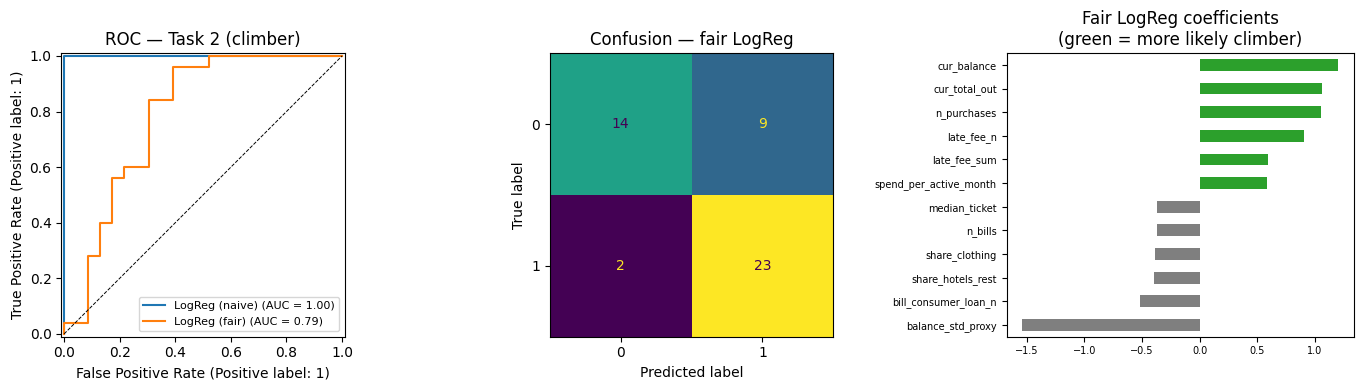

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for tag, cols, colr in [("naive", ALL_COLS, "tab:gray"), ("fair", FAIR_COLS, "tab:green")]:
    X = Xframe(feats_deb, cols)
    Xtr, Xte, ytr, yte = train_test_split(X, y_cli, test_size=0.3, stratify=y_cli, random_state=0)
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")).fit(Xtr, ytr)
    RocCurveDisplay.from_estimator(clf, Xte, yte, ax=ax[0], name=f"LogReg ({tag})")
    if tag == "fair":
        ConfusionMatrixDisplay.from_estimator(clf, Xte, yte, ax=ax[1], colorbar=False)
        ax[1].set_title("Confusion — fair LogReg")
ax[0].plot([0, 1], [0, 1], "k--", lw=0.7); ax[0].set_title("ROC — Task 2 (climber)"); ax[0].legend(fontsize=8)
# same collinearity caveat as Task 1 -- coefficients only, not the AUC table.
COEF_COLS = F.interpretable_columns(FAIR_COLS)
Xf = Xframe(feats_deb, COEF_COLS)
coef = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, class_weight="balanced")).fit(Xf, y_cli)
imp = pd.Series(coef.named_steps["logisticregression"].coef_[0], index=COEF_COLS).sort_values()
top = pd.concat([imp.head(6), imp.tail(6)])
top.plot.barh(ax=ax[2], color=(top > 0).map({True: "tab:green", False: "tab:gray"}))
ax[2].set_title("Fair LogReg coefficients\n(green = more likely climber)"); ax[2].tick_params(labelsize=7)
fig.tight_layout(); plt.show()

**Reading Task 2.** Among debtors, the **naive** model again nearly separates climbers
(**AUC 0.997**) — their debt trajectory falls to zero, a dead giveaway. The **fair** model
reaches **0.839 (LogReg) / 0.850 (random forest)**, and — unlike Task 1 — this barely moved
when `cur_n_entries` was reclassified (0.842 → 0.839). So the climber signal is *not* a
leakage artefact: climbers genuinely differ from chronic/subsister debtors in ordinary ways
(higher income, healthier balance dynamics, fewer late fees), because the archetype draw is
tilted by financial vulnerability and the divergent repayment rules then compound that
difference in the ordinary account record.

Note the asymmetry with the clustering result: *unsupervised* fair recovery of the subtypes is
weak (ARI 0.200), while *supervised* fair prediction of climber-vs-other is strong (0.839).
Both are true — supervision can find a weak, low-variance direction that clustering, driven by
the dominant income/spend axis, will not isolate on its own.

## 4b · Task 3 — who is a **saver**? *(all consumers)*

The same two questions as Task 1, asked of the other label — and the reason this section
exists is what it exposed about the feature set.

`FAIR_COLS` quarantines what mechanically encodes *debtor* status. On the **saver** label
it is not fair at all: `Consumer._month_close` sweeps the month's positive residual into
savings or pension, and that sweep is a **debit on the current account**, so
`cur_total_out` counts a line only savers ever have and `cur_balance` is what is left
after it. Hence three feature sets below, not two — `debtor-fair` is the middle column and
the point of the exercise.

In [ ]:
# Task 3 — is_saver under THREE feature sets. The middle one is the point.
SAVER_FAIR_COLS = F.saver_fair_columns(feats)
y_sav = data["is_saver"].astype(int)
print("class balance:", y_sav.value_counts().to_dict())
print(f"saver-fair: {len(SAVER_FAIR_COLS)} cols = fair ({len(FAIR_COLS)}) "
      f"minus {list(F.LEAK_SAVER)}")

rows = []
for tag, cols in (("naive", ALL_COLS), ("debtor-fair", FAIR_COLS),
                  ("saver-fair", SAVER_FAIR_COLS)):
    X = Xframe(feats, cols)
    for name, mdl in (("LogReg", make_pipeline(
                          StandardScaler(),
                          LogisticRegression(max_iter=2000, class_weight="balanced"))),
                      ("RF", RandomForestClassifier(n_estimators=300, random_state=0,
                                                    class_weight="balanced"))):
        rows.append({"features": tag, "n": len(cols), "model": name,
                     "AUC": cross_val_score(mdl, X, y_sav, cv=5,
                                            scoring="roc_auc").mean()})
saver_pred = pd.DataFrame(rows).pivot(index=["features", "n"], columns="model",
                                      values="AUC")
display(saver_pred.round(4))

# The audit: correlating with the label is NOT what makes a column unfair — mechanically
# encoding it is. Three columns correlate about as strongly and are kept.
print("\ncorrelation with is_saver:")
for col in list(F.LEAK_SAVER) + ["balance_std_proxy", "cur_total_in", "mean_income_credit"]:
    v = np.log1p(data[col].clip(lower=0)) if col in MONEY_COLS else data[col]
    mark = "QUARANTINED" if col in F.LEAK_SAVER else "kept"
    print(f"  {col:22s} {np.corrcoef(v, y_sav)[0, 1]:+.3f}   {mark}")

frac = (data.loc[~data["is_saver"], "LEAK_savings_balance"] == 0).mean()
print(f"\nLEAK_savings_balance == 0 for {frac:.0%} of non-savers (definitionally the label)")

# Known confound: subsisters are force-set is_saver=True in _assign_savings.
print("\nsaver rate by debtor subtype (the confound):")
print(data.groupby("debtor_subtype")["is_saver"].agg(["sum", "count", "mean"]).round(3))

# ROC curves: the leak, visually.
fig, ax = plt.subplots(figsize=(5.5, 5))
X_tr, X_te, y_tr, y_te = train_test_split(data, y_sav, test_size=0.3, stratify=y_sav,
                                          random_state=0)
for tag, cols in (("naive", ALL_COLS), ("debtor-fair", FAIR_COLS),
                  ("saver-fair", SAVER_FAIR_COLS)):
    clf = make_pipeline(StandardScaler(),
                        LogisticRegression(max_iter=2000, class_weight="balanced"))
    clf.fit(Xframe(X_tr, cols), y_tr)
    RocCurveDisplay.from_estimator(clf, Xframe(X_te, cols), y_te, name=tag, ax=ax)
ax.plot([0, 1], [0, 1], "k--", lw=0.8)
ax.set_title("is_saver — the sweep leak, visually")
fig.tight_layout(); plt.show()


**Reading Task 3.** `debtor-fair` scores **≈ 0.995** — the set this repo calls "fair"
effectively knows the answer. Quarantining just `cur_total_out` and `cur_balance` as
`LEAK_SAVER` takes the honest number to **≈ 0.83**. Same class of bug as
`LEAK_cur_n_entries`, found only by asking the question of a *new label*.

Note what is **not** quarantined. `balance_std_proxy` correlates +0.40 and stays: it is
built from the transaction stream, and sweeps are never written to `model.transactions`.
`cur_total_in` correlates +0.30 and stays: the sweep *credits* savings/pension and never
touches the current account. Correlation is not the test — **mechanical encoding is.**

Honest saver prediction (0.83) clearly beats honest debtor prediction (0.70), and the
reason is structural: `numbers.is_saver(rng, income_quintile)` draws the flag conditional
on **income quintile**, which the ledger *does* reveal through the income credits. The
debtor subtype is drawn on a *hidden* vulnerability flag. This label has an observable
cause, so behaviour genuinely carries it.

**Confound, declared:** `ItalyModel._assign_savings` force-sets `is_saver = True` for
subsisters, so all 36 of them are savers and the two labels are entangled.

## 5 · Takeaways

All numbers below are measured at 800 consumers x 720 days, seed 42, by the cells above.

- **The behaviours are faithfully encoded.** Naive models recover both labels almost perfectly
  (AUC 1.000 for debtor, 0.997 for climber) — the synthetic stream really does carry the
  debtor/climber signal.
- **Ordinary behaviour is modestly predictive of debt, and clearly predictive of climbing.**
  With every debt-mechanic proxy removed: debtor AUC **0.697 / 0.745** (LogReg / RF), climber
  AUC **0.839 / 0.850**. Debt *assignment* is close to a coin flip conditional on
  vulnerability — `sample_debtor_subtype` draws it rather than causing it — so the fair ceiling
  on Task 1 is a property of the generator, not a modelling shortfall. Climbing is easier
  because the repayment rules that follow the draw leave an ordinary, visible trace.
- **The leakage lesson is real, and it bit this notebook.** The fair Task-1 AUC read 0.91 until
  an audit found that `cur_n_entries` — an innocuous-looking count of current-account entries —
  silently included the debt-service, credit-draw and overdraft lines. Reclassifying it as
  `LEAK_cur_n_entries` moved the honest number to 0.697. A feature is not fair because its name
  is innocuous; it is fair only if the generating process cannot write the label into it.
- **As a student task** this is now a clean three-part exercise: (1) build the features and
  obtain ~perfect accuracy, (2) discover the obvious leakage, remove it, and find the honest
  signal, and (3) discover the *non-obvious* leakage still hiding in a fair-looking column.

*Circularity caveat (again): these results validate that the model's intended behavioural
separation is learnable from its output; they are not evidence about predicting debt in real
populations.*